Explained Variance: PC1 = 31.00%, PC2 = 24.92%
Total Explained Variance: 55.92%

PCA Loadings (Weights):
                                PC1       PC2
Cost Per Meal              0.410546  0.320559
GROCPTH20                  0.598008 -0.288532
No_SNAP_Below_Poverty_Gap  0.178819  0.702050
mean_commute_time         -0.350447  0.536318
pct_households_no_vehicle  0.564845  0.182973


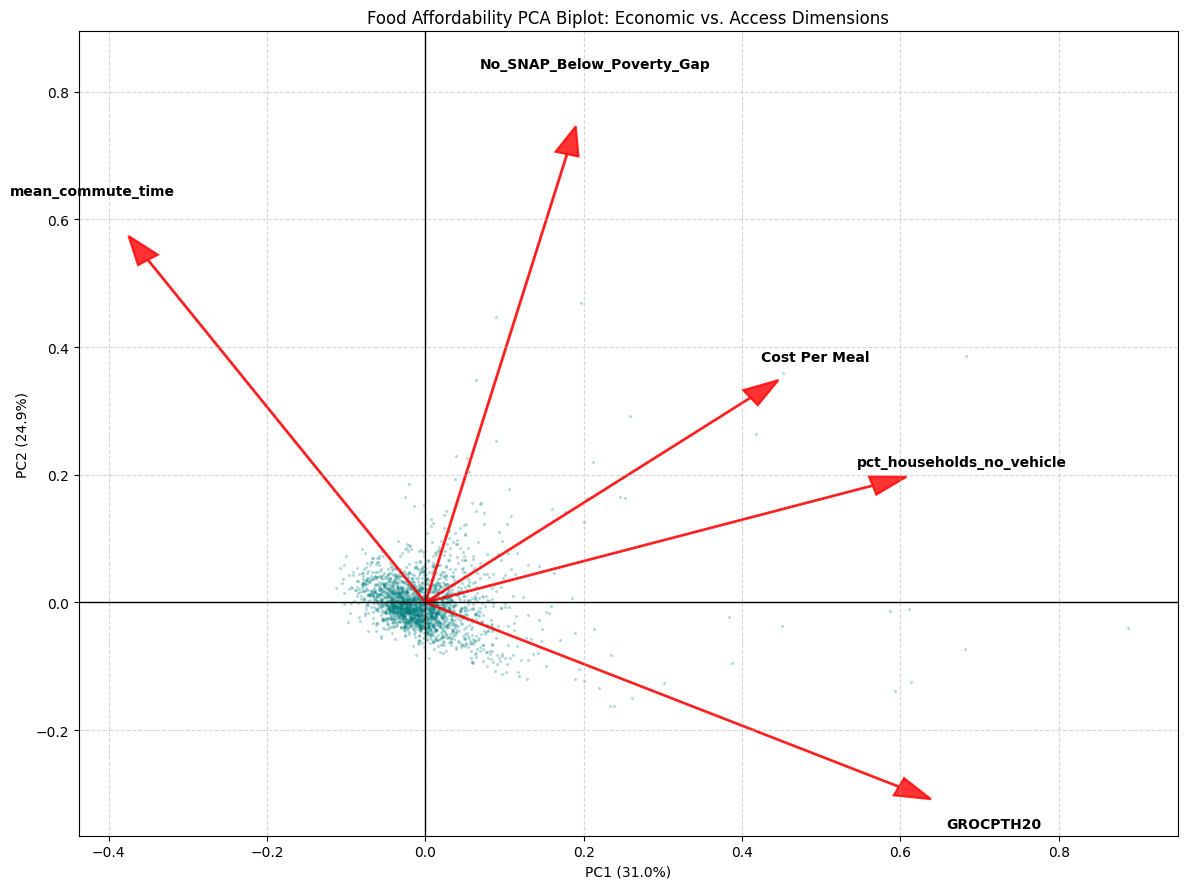


Success: Saved PCA-transformed data to 'final_master_with_pca.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
# Replace the filename if yours is different
df = pd.read_csv('final_master_with_medicare_2023.csv')

# 2. Define the 5 key embedding variables
embedding_vars = [
    'Cost Per Meal',
    'GROCPTH20',
    'No_SNAP_Below_Poverty_Gap',
    'mean_commute_time',
    'pct_households_no_vehicle'
]

# 3. Preprocessing: Handle missing values and scale
# PCA cannot handle NaNs. We drop rows with missing values in our 5 variables.
df_clean = df.dropna(subset=embedding_vars).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[embedding_vars])

# 4. Run PCA with 2 components
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

# Add the PCA results back to the dataframe for future use
df_clean['PC1'] = pca_features[:, 0]
df_clean['PC2'] = pca_features[:, 1]

# 5. Output Explained Variance
explained_var = pca.explained_variance_ratio_
print(f"Explained Variance: PC1 = {explained_var[0]:.2%}, PC2 = {explained_var[1]:.2%}")
print(f"Total Explained Variance: {sum(explained_var):.2%}")

# 6. Output Loadings (Interpretation Table)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=embedding_vars
)
print("\nPCA Loadings (Weights):")
print(loadings)

# 7. Visualization: Biplot
def render_biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    
    # Scale scores to fit -1 to 1 for better visual alignment with arrows
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    
    plt.figure(figsize=(12, 9))
    
    # Scatter plot of counties
    plt.scatter(xs * scalex, ys * scaley, alpha=0.2, s=2, color='teal')
    
    # Plot vectors (arrows)
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0], coeff[i, 1], color='red', alpha=0.8, 
                  head_width=0.03, linewidth=1.5)
        if labels is not None:
            plt.text(coeff[i, 0] * 1.2, coeff[i, 1] * 1.2, labels[i], 
                     color='black', ha='center', va='center', weight='bold')

    plt.xlabel(f"PC1 ({explained_var[0]:.1%})")
    plt.ylabel(f"PC2 ({explained_var[1]:.1%})")
    plt.title("Food Affordability PCA Biplot: Economic vs. Access Dimensions")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.tight_layout()
    plt.savefig('pca_results_biplot.png')
    plt.show()

render_biplot(pca_features, pca.components_.T, labels=embedding_vars)

# 8. Export the data with latent dimensions for DML
df_clean.to_csv('final_master_with_pca.csv', index=False)
print("\nSuccess: Saved PCA-transformed data to 'final_master_with_pca.csv'")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================================
# PART 1: DATA LOADING AND PREPROCESSING
# ============================================================================

print("\n" + "="*70)
print("PART 1: DATA LOADING AND PREPROCESSING")
print("="*70)

# Load dataset
df = pd.read_csv('final_master_with_medicare_2023.csv')
print(f"\nDataset shape: {df.shape}")

# Define the 5 affordability variables
affordability_vars = [
    'Cost Per Meal',
    'GROCPTH20',
    'No_SNAP_Below_Poverty_Gap',
    'mean_commute_time',
    'pct_households_no_vehicle'
]

print(f"\nAffordability variables: {affordability_vars}")

# Clean data: drop rows with missing values in affordability variables
df_clean = df.dropna(subset=affordability_vars).copy()
print(f"Rows after dropping NaN: {len(df_clean)}")

# Extract affordability data
X = df_clean[affordability_vars].values
print(f"\nAffordability matrix shape: {X.shape}")

# Standardize the data (critical for autoencoders)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardization complete.")
print("Mean per variable (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Std per variable (should be ~1):", X_scaled.std(axis=0).round(4))

# Train/validation split
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# ============================================================================
# PART 2: AUTOENCODER ARCHITECTURE DEFINITION
# ============================================================================

print("\n" + "="*70)
print("PART 2: AUTOENCODER ARCHITECTURE")
print("="*70)

def build_autoencoder(input_dim, hidden_dim, latent_dim):
    """
    Build a shallow autoencoder.
    
    Architecture:
    Input (5) → Hidden (ReLU) → Bottleneck (Linear) → Hidden (ReLU) → Output (Linear)
    
    Args:
        input_dim: Number of input features (5)
        hidden_dim: Number of neurons in hidden layer (4, 6, or 8)
        latent_dim: Number of latent dimensions (2, 3, or 4)
    
    Returns:
        autoencoder: Full autoencoder model
        encoder: Encoder-only model (for generating embeddings)
    """
    
    # Encoder
    input_layer = layers.Input(shape=(input_dim,), name='input')
    hidden_enc = layers.Dense(hidden_dim, activation='relu', name='encoder_hidden')(input_layer)
    latent = layers.Dense(latent_dim, activation='linear', name='latent_bottleneck')(hidden_enc)
    
    # Decoder
    hidden_dec = layers.Dense(hidden_dim, activation='relu', name='decoder_hidden')(latent)
    output_layer = layers.Dense(input_dim, activation='linear', name='output')(hidden_dec)
    
    # Full autoencoder
    autoencoder = models.Model(inputs=input_layer, outputs=output_layer, name='autoencoder')
    
    # Encoder only (for generating embeddings)
    encoder = models.Model(inputs=input_layer, outputs=latent, name='encoder')
    
    return autoencoder, encoder

# Example architecture visualization
print("\nAutoencoder Architecture:")
print("="*50)
print("Layer 1: Input          → 5 neurons")
print("Layer 2: Hidden (ReLU)  → [4, 6, or 8] neurons")
print("Layer 3: Latent (Linear)→ [2, 3, or 4] neurons  ← BOTTLENECK")
print("Layer 4: Hidden (ReLU)  → [4, 6, or 8] neurons")
print("Layer 5: Output (Linear)→ 5 neurons")
print("="*50)
print("\nObjective: Minimize reconstruction error (MSE)")
print("Training: Only on 5 affordability variables")
print("No health outcomes used during training!")

# ============================================================================
# PART 3: TRAINING AUTOENCODERS - ALL CONFIGURATIONS
# ============================================================================

print("\n" + "="*70)
print("PART 3: TRAINING AUTOENCODERS")
print("="*70)

# Configuration grid
hidden_dims = [4, 6, 8]
latent_dims = [2, 3, 4]

# Storage for results
results = []
trained_models = {}

# Training loop
for hidden_dim in hidden_dims:
    for latent_dim in latent_dims:
        
        config_name = f"hidden{hidden_dim}_latent{latent_dim}"
        print(f"\n{'='*60}")
        print(f"Training: Hidden={hidden_dim}, Latent={latent_dim}")
        print(f"{'='*60}")
        
        # Build model
        autoencoder, encoder = build_autoencoder(
            input_dim=5,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim
        )
        
        # Compile
        autoencoder.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )
        
        # Callbacks
        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )
        
        # Train
        history = autoencoder.fit(
            X_train, X_train,
            epochs=200,
            batch_size=32,
            validation_data=(X_val, X_val),
            callbacks=[early_stop],
            verbose=0
        )
        
        # Evaluate
        train_loss = autoencoder.evaluate(X_train, X_train, verbose=0)[0]
        val_loss = autoencoder.evaluate(X_val, X_val, verbose=0)[0]
        
        # Store results
        results.append({
            'hidden_dim': hidden_dim,
            'latent_dim': latent_dim,
            'train_mse': train_loss,
            'val_mse': val_loss,
            'epochs_trained': len(history.history['loss']),
            'config_name': config_name
        })
        
        # Store models
        trained_models[config_name] = {
            'autoencoder': autoencoder,
            'encoder': encoder,
            'history': history
        }
        
        print(f"✓ Train MSE: {train_loss:.6f}")
        print(f"✓ Val MSE: {val_loss:.6f}")
        print(f"✓ Epochs: {len(history.history['loss'])}")

# Results summary
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("TRAINING RESULTS SUMMARY")
print("="*70)
print(results_df.to_string(index=False))

# Find best configuration for each latent dimension
print("\n" + "="*70)
print("BEST MODELS PER LATENT DIMENSION (by validation MSE)")
print("="*70)
for latent_dim in latent_dims:
    best = results_df[results_df['latent_dim'] == latent_dim].sort_values('val_mse').iloc[0]
    print(f"\nLatent Dim = {latent_dim}:")
    print(f"  Best Hidden Dim: {int(best['hidden_dim'])}")
    print(f"  Val MSE: {best['val_mse']:.6f}")
    print(f"  Config: {best['config_name']}")

# ============================================================================
# PART 4: PCA COMPARISON BASELINE
# ============================================================================

print("\n" + "="*70)
print("PART 4: PCA COMPARISON BASELINE")
print("="*70)

pca_results = {}
for n_components in [2, 3, 4]:
    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)
    
    # Reconstruction
    X_pca_transformed = pca.transform(X_scaled)
    X_pca_reconstructed = pca.inverse_transform(X_pca_transformed)
    
    # MSE
    pca_mse = np.mean((X_scaled - X_pca_reconstructed) ** 2)
    
    pca_results[n_components] = {
        'mse': pca_mse,
        'variance_explained': pca.explained_variance_ratio_.sum(),
        'pca_object': pca
    }
    
    print(f"\nPCA with {n_components} components:")
    print(f"  Reconstruction MSE: {pca_mse:.6f}")
    print(f"  Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

# ============================================================================
# PART 5: AUTOENCODER VS PCA COMPARISON
# ============================================================================

print("\n" + "="*70)
print("PART 5: AUTOENCODER VS PCA - RECONSTRUCTION ERROR COMPARISON")
print("="*70)

comparison_data = []

for latent_dim in latent_dims:
    # Get best autoencoder for this latent dimension
    best_ae_config = results_df[results_df['latent_dim'] == latent_dim].sort_values('val_mse').iloc[0]
    ae_mse = best_ae_config['val_mse']
    
    # Get PCA result
    pca_mse = pca_results[latent_dim]['mse']
    
    comparison_data.append({
        'Latent_Dims': latent_dim,
        'Autoencoder_MSE': ae_mse,
        'PCA_MSE': pca_mse,
        'AE_Better': ae_mse < pca_mse,
        'Improvement_%': ((pca_mse - ae_mse) / pca_mse * 100) if ae_mse < pca_mse else 0
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# ============================================================================
# PART 6: GENERATE LATENT EMBEDDINGS
# ============================================================================

print("\n" + "="*70)
print("PART 6: GENERATING LATENT EMBEDDINGS")
print("="*70)

# For each latent dimension, use the best autoencoder configuration
for latent_dim in latent_dims:
    # Find best config
    best_config = results_df[results_df['latent_dim'] == latent_dim].sort_values('val_mse').iloc[0]
    config_name = best_config['config_name']
    
    # Get encoder
    encoder = trained_models[config_name]['encoder']
    
    # Generate embeddings
    latent_embeddings = encoder.predict(X_scaled, verbose=0)
    
    # Create output dataframe
    output_df = df_clean[['FIPS']].copy()
    
    for i in range(latent_dim):
        output_df[f'AE_latent_{i+1}'] = latent_embeddings[:, i]
    
    # Save
    filename = f'autoencoder_latent_{latent_dim}d.csv'
    output_df.to_csv(filename, index=False)
    
    print(f"\n✓ Saved: {filename}")
    print(f"  Config: {config_name}")
    print(f"  Shape: {output_df.shape}")
    print(f"  Columns: {list(output_df.columns)}")

# Also save the full dataset with all embeddings
df_with_embeddings = df_clean.copy()

for latent_dim in latent_dims:
    best_config = results_df[results_df['latent_dim'] == latent_dim].sort_values('val_mse').iloc[0]
    config_name = best_config['config_name']
    encoder = trained_models[config_name]['encoder']
    latent_embeddings = encoder.predict(X_scaled, verbose=0)
    
    for i in range(latent_dim):
        df_with_embeddings[f'AE{latent_dim}d_latent{i+1}'] = latent_embeddings[:, i]

df_with_embeddings.to_csv('final_master_with_autoencoder_embeddings.csv', index=False)
print(f"\n✓ Saved: final_master_with_autoencoder_embeddings.csv")
print(f"  All latent embeddings (2D, 3D, 4D) included")

print("\n" + "="*70)
print("AUTOENCODER TRAINING COMPLETE!")
print("="*70)


TensorFlow version: 2.20.0
GPU Available: []

PART 1: DATA LOADING AND PREPROCESSING

Dataset shape: (3134, 48)

Affordability variables: ['Cost Per Meal', 'GROCPTH20', 'No_SNAP_Below_Poverty_Gap', 'mean_commute_time', 'pct_households_no_vehicle']
Rows after dropping NaN: 2226

Affordability matrix shape: (2226, 5)

Standardization complete.
Mean per variable (should be ~0): [-0. -0. -0. -0.  0.]
Std per variable (should be ~1): [1. 1. 1. 1. 1.]

Train set: 1780 samples
Validation set: 446 samples

PART 2: AUTOENCODER ARCHITECTURE

Autoencoder Architecture:
Layer 1: Input          → 5 neurons
Layer 2: Hidden (ReLU)  → [4, 6, or 8] neurons
Layer 3: Latent (Linear)→ [2, 3, or 4] neurons  ← BOTTLENECK
Layer 4: Hidden (ReLU)  → [4, 6, or 8] neurons
Layer 5: Output (Linear)→ 5 neurons

Objective: Minimize reconstruction error (MSE)
Training: Only on 5 affordability variables
No health outcomes used during training!

PART 3: TRAINING AUTOENCODERS

Training: Hidden=4, Latent=2
✓ Train MSE: 0.

Training models for comparison... this may take a moment.


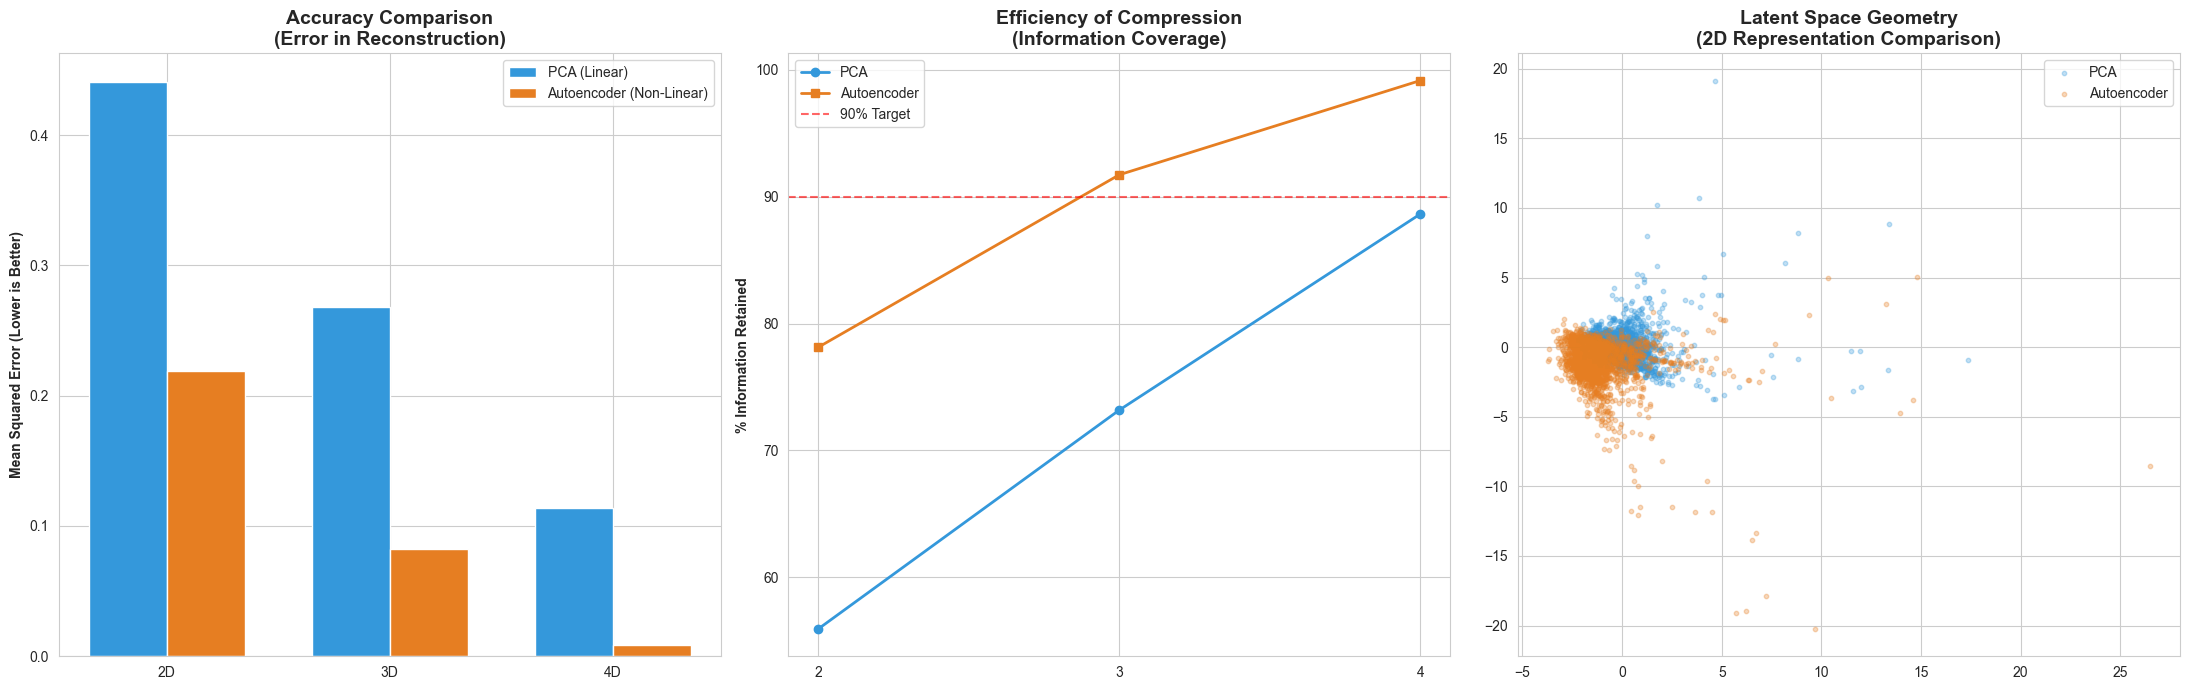


Process Complete! Image saved as 'PCA_vs_AE_Final_Comparison.png'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. SETUP & DATA PREPARATION
# ==========================================
df = pd.read_csv('final_master_with_medicare_2023.csv')
affordability_vars = [
    'Cost Per Meal', 'GROCPTH20', 'No_SNAP_Below_Poverty_Gap', 
    'mean_commute_time', 'pct_households_no_vehicle'
]
df_clean = df.dropna(subset=affordability_vars).copy()
X = StandardScaler().fit_transform(df_clean[affordability_vars])

# ==========================================
# 2. RUN MODELS & COLLECT ERRORS
# ==========================================
dims = [2, 3, 4]
pca_mse = []
ae_mse = []
pca_2d_features = None
ae_2d_features = None

def get_ae(latent_dim):
    """
    Builds the autoencoder using the Functional API 
    (Avoids the AttributeError by explicitly defining the Input tensor)
    """
    # Define layers
    inputs = layers.Input(shape=(5,), name='input_layer')
    enc_hidden = layers.Dense(8, activation='relu', name='encoder_hidden')(inputs)
    bottleneck = layers.Dense(latent_dim, activation='linear', name='bottleneck')(enc_hidden)
    dec_hidden = layers.Dense(8, activation='relu', name='decoder_hidden')(bottleneck)
    outputs = layers.Dense(5, activation='linear', name='output_layer')(dec_hidden)
    
    # Define the full model
    autoencoder = models.Model(inputs=inputs, outputs=outputs)
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # Also return the encoder part separately to make feature extraction easy
    encoder = models.Model(inputs=inputs, outputs=bottleneck)
    
    return autoencoder, encoder

print("Training models for comparison... this may take a moment.")

for d in dims:
    # --- PCA ---
    pca = PCA(n_components=d)
    X_pca = pca.fit_transform(X)
    X_pca_recon = pca.inverse_transform(X_pca)
    pmse = np.mean((X - X_pca_recon)**2)
    pca_mse.append(pmse)
    if d == 2: pca_2d_features = X_pca
        
    # --- Autoencoder ---
    ae_full, encoder_only = get_ae(d)
    # Train the autoencoder
    ae_full.fit(X, X, epochs=150, batch_size=32, verbose=0)
    
    # Calculate error
    amse = ae_full.evaluate(X, X, verbose=0)
    ae_mse.append(amse)
    
    # Store 2D embeddings for the plot
    if d == 2:
        ae_2d_features = encoder_only.predict(X, verbose=0)

# ==========================================
# 3. GENERATE VISUALIZATIONS
# ==========================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# GRAPH 1: Reconstruction Error (Bar Chart)
x_pos = np.arange(len(dims))
width = 0.35
axes[0].bar(x_pos - width/2, pca_mse, width, label='PCA (Linear)', color='#3498db')
axes[0].bar(x_pos + width/2, ae_mse, width, label='Autoencoder (Non-Linear)', color='#e67e22')
axes[0].set_ylabel('Mean Squared Error (Lower is Better)', fontweight='bold')
axes[0].set_title('Accuracy Comparison\n(Error in Reconstruction)', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'{d}D' for d in dims])
axes[0].legend()

# GRAPH 2: Information Retention (Line Chart)
pca_pct = [(1 - e)*100 for e in pca_mse]
ae_pct = [(1 - e)*100 for e in ae_mse]
axes[1].plot(dims, pca_pct, marker='o', color='#3498db', label='PCA', linewidth=2)
axes[1].plot(dims, ae_pct, marker='s', color='#e67e22', label='Autoencoder', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.6, label='90% Target')
axes[1].set_ylabel('% Information Retained', fontweight='bold')
axes[1].set_title('Efficiency of Compression\n(Information Coverage)', fontsize=14, fontweight='bold')
axes[1].set_xticks(dims)
axes[1].legend()

# GRAPH 3: Latent Space Scatter (2D)
axes[2].scatter(pca_2d_features[:, 0], pca_2d_features[:, 1], alpha=0.3, s=10, label='PCA', color='#3498db')
axes[2].scatter(ae_2d_features[:, 0], ae_2d_features[:, 1], alpha=0.3, s=10, label='Autoencoder', color='#e67e22')
axes[2].set_title('Latent Space Geometry\n(2D Representation Comparison)', fontsize=14, fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('PCA_vs_AE_Final_Comparison.png', dpi=200)
plt.show()

print("\nProcess Complete! Image saved as 'PCA_vs_AE_Final_Comparison.png'")

In [15]:
import pandas as pd
import geopandas as gpd
from libpysal.weights import Queen, lag_spatial
import os

# --- 1. Load the Autoencoder Results ---
# This file was just created in your MERGED DATA folder
df_embed = pd.read_csv('final_master_with_autoencoder_embeddings.csv')
df_embed['FIPS'] = df_embed['FIPS'].astype(str).str.zfill(5)

# --- 2. Load the Map from the sub-folder ---
# Since you are in 'MERGED DATA', we go into the folder shown in your image
shapefile_path = 'cb_2018_us_county_500k/cb_2018_us_county_500k.shp'

print(f"Looking for shapefile at: {os.path.abspath(shapefile_path)}")

if os.path.exists(shapefile_path):
    gdf_counties = gpd.read_file(shapefile_path)
    
    # Standardize FIPS/GEOID
    gdf_counties = gdf_counties.rename(columns={'GEOID': 'FIPS'})
    gdf_counties['FIPS'] = gdf_counties['FIPS'].astype(str).str.zfill(5)

    # --- 3. Merge Data with Geography ---
    # This turns your list of numbers into a 'Spatially Aware' Map
    gdf = gdf_counties.merge(df_embed, on='FIPS', how='inner')
    print(f"Successfully merged! Working with {len(gdf)} counties.")

    # 

    # --- 4. Define the Neighbors (Spatial Weights) ---
    # Queen contiguity means counties that share a border or a corner are neighbors
    print("Finding neighbors for each county...")
    w = Queen.from_dataframe(gdf)
    w.transform = 'R' # Row-standardize to get the "Average of Neighbors"

    # 

    # --- 5. Compute WX (The Spatial Spillover) ---
    # We are calculating the average AI-affordability score of all touching counties
    print("Calculating WX (Neighboring AI Scores)...")
    gdf['WX_AE_1'] = lag_spatial(w, gdf['AE3d_latent1'])
    gdf['WX_AE_2'] = lag_spatial(w, gdf['AE3d_latent2'])
    gdf['WX_AE_3'] = lag_spatial(w, gdf['AE3d_latent3'])

    # --- 6. Save the Final ML Ready Dataset ---
    # We drop the heavy geometry shapes to make a clean CSV for Arul's ML models
    final_df = pd.DataFrame(gdf.drop(columns='geometry'))
    final_df.to_csv('final_spatial_ml_dataset.csv', index=False)
    
    print("\n--- PHASE 3 SUCCESS ---")
    print("Your data is now spatially engineered. File saved as: 'final_spatial_ml_dataset.csv'")
    
else:
    print("Error: Could not find the .shp file. Double-check that the folder name is spelled exactly 'cb_2018_us_county_500k' in your MERGED DATA folder.")

Looking for shapefile at: C:\Users\Arul\Desktop\JHU\Capstone Project\Data\Merged Data\cb_2018_us_county_500k\cb_2018_us_county_500k.shp
Successfully merged! Working with 2226 counties.
Finding neighbors for each county...


C:\Users\Arul\AppData\Local\Temp\ipykernel_20404\618010619.py:34: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\Arul\anaconda3\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 35 disconnected components.
 There are 20 islands with ids: 67, 212, 213, 256, 400, 498, 650, 732, 748, 894, 959, 995, 1025, 1074, 1162, 1183, 1348, 1647, 1882, 2124.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 67, ' is an island (no neighbors)')
('WARNING: ', 212, ' is an island (no neighbors)')
('WARNING: ', 213, ' is an island (no neighbors)')
('WARNING: ', 256, ' is an island (no neighbors)')
('WARNING: ', 400, ' is an island (no neighbors)')
('WARNING: ', 498, ' is an island (no neighbors)')
('WARNING: ', 650, ' is an island (no neighbors)')
('WARNING: ', 732, ' is an island (no neighbors)')
('WARNING: ', 748, ' is an island (no neighbors)')
('WARNING: ', 894, ' is an island (no neighbors)')
('WARNING: ', 959, ' is an island (no neighbors)')
('WARNING: ', 995, ' is an island (no neighbors)')
('WARNING: ', 1025, ' is an island (no neighbors)')
('WARNING: ', 1074, ' is an island (no neighbors)')
('WARNING: ', 1162, ' is an island (no neighbors)')
('WARNING: ', 1183, ' is an island (no neighbors)')
('WARNING: ', 1348, ' is an island (no neighbors)')
('WARNING: ', 1647, ' is an island (no neighbors)')
('WARNING: ', 1882, ' is an island (no neighbors)')
('WARNING: ', 2124, ' is 

In [5]:
import pandas as pd
import geopandas as gpd
from libpysal.weights import Queen
from libpysal.weights.spatial_lag import lag_spatial

# 1. Load your dataset and the shapefile
df = pd.read_csv('final_spatial_ml_dataset 2.csv')

# Make sure FIPS is treated as a string with leading zeros for the merge
df['FIPS'] = df['FIPS'].astype(str).str.zfill(5)

# Load the shapefile using the path from your screenshot
gdf_boundaries = gpd.read_file('cb_2018_us_county_500k/cb_2018_us_county_500k.shp')
gdf_boundaries['GEOID'] = gdf_boundaries['GEOID'].astype(str).str.zfill(5)

# 2. Merge and create weights
# We merge on GEOID/FIPS to link the data to the geography
gdf = gdf_boundaries.merge(df, left_on='GEOID', right_on='FIPS')

# Create the spatial weights (Queen contiguity: sharing a border or corner)
w = Queen.from_dataframe(gdf)
w.transform = 'R' # Row-standardize (averages the neighbors)

# 3. Create spatial lags for your RAW food variables
raw_vars = ['Cost Per Meal', 'GROCPTH20', 'No_SNAP_Below_Poverty_Gap', 'mean_commute_time', 'pct_households_no_vehicle']

print("Calculating spatial lags...")
for col in raw_vars:
    gdf[f'WX_{col}'] = lag_spatial(w, gdf[col])

# 4. Save this as your new master file for the triple baseline
gdf.drop(columns='geometry').to_csv('baseline_with_raw_spatial.csv', index=False)
print("✅ Done! File 'baseline_with_raw_spatial.csv' is ready for the experiments.")

C:\Users\Arul\AppData\Local\Temp\ipykernel_16840\4024151354.py:21: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
C:\Users\Arul\anaconda3\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 35 disconnected components.
 There are 20 islands with ids: 67, 212, 213, 256, 400, 498, 650, 732, 748, 894, 959, 995, 1025, 1074, 1162, 1183, 1348, 1647, 1882, 2124.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 67, ' is an island (no neighbors)')
('WARNING: ', 212, ' is an island (no neighbors)')
('WARNING: ', 213, ' is an island (no neighbors)')
('WARNING: ', 256, ' is an island (no neighbors)')
('WARNING: ', 400, ' is an island (no neighbors)')
('WARNING: ', 498, ' is an island (no neighbors)')
('WARNING: ', 650, ' is an island (no neighbors)')
('WARNING: ', 732, ' is an island (no neighbors)')
('WARNING: ', 748, ' is an island (no neighbors)')
('WARNING: ', 894, ' is an island (no neighbors)')
('WARNING: ', 959, ' is an island (no neighbors)')
('WARNING: ', 995, ' is an island (no neighbors)')
('WARNING: ', 1025, ' is an island (no neighbors)')
('WARNING: ', 1074, ' is an island (no neighbors)')
('WARNING: ', 1162, ' is an island (no neighbors)')
('WARNING: ', 1183, ' is an island (no neighbors)')
('WARNING: ', 1348, ' is an island (no neighbors)')
('WARNING: ', 1647, ' is an island (no neighbors)')
('WARNING: ', 1882, ' is an island (no neighbors)')
('WARNING: ', 2124, ' is 

In [9]:
import pandas as pd
import numpy as np
import itertools
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
import os

# 1. LOAD DATA
df = pd.read_csv('baseline_with_raw_spatial.csv')

# 2. DEFINITIONS
CONTROLS = ['min_wage_2023', 'poverty_rate', 'population_density', 'Median_Household_Income', 'percent_65_plus'] 
RAW_FEATURES = ['Cost Per Meal', 'GROCPTH20', 'No_SNAP_Below_Poverty_Gap', 'mean_commute_time', 'pct_households_no_vehicle']
SPATIAL_LAG_FEATURES = [f'WX_{col}' for col in RAW_FEATURES]

OUTCOMES = {
    'obesity_rate': 'Obesity Rate (%)',
    'diabetes_rate': 'Diabetes Rate (%)',
    'TOT_MDCR_STDZD_PYMT_PC': 'Medicare Cost Per Capita ($)'
}

EXPERIMENTS = [
    ('Exp 1: Controls Only', CONTROLS),
    ('Exp 2: Raw Vars + Controls', RAW_FEATURES + CONTROLS),
    ('Exp 3: Raw Vars + Controls + Spatial', RAW_FEATURES + CONTROLS + SPATIAL_LAG_FEATURES)
]

# 3. MATCHING FRIEND'S EXACT GRID SEARCH PARAMETERS
PARAM_GRIDS = {
    'RandomForest': {
        'n_estimators':     [100, 200],
        'max_depth':        [6, 10, None],
        'min_samples_leaf': [3, 5, 10],
        'max_features':     ['sqrt', 0.5, None],
    },
    'XGBoost': {
        'n_estimators':    [100, 200],
        'max_depth':       [4, 6, 8],
        'learning_rate':   [0.05, 0.1, 0.2],
        'subsample':       [0.7, 0.9],
        'colsample_bytree': [0.7, 0.9],
    }
}

def _make_base_model(model_name, params):
    if model_name == 'RandomForest':
        return RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    elif model_name == 'XGBoost':
        return XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)

# 4. FRIEND'S EXACT INNER TUNING FUNCTION
def tune_hyperparams(X_train_val, y_train_val, state_groups, model_name):
    gkf = GroupKFold(n_splits=3)
    grid = PARAM_GRIDS[model_name]
    keys = list(grid.keys())
    combos = list(itertools.product(*grid.values()))

    best_r2, best_params = -np.inf, None

    for combo in combos:
        params = dict(zip(keys, combo))
        fold_r2s = []

        for inner_train_idx, inner_val_idx in gkf.split(X_train_val, y_train_val, groups=state_groups):
            X_t, X_v = X_train_val[inner_train_idx], X_train_val[inner_val_idx]
            y_t = y_train_val.iloc[inner_train_idx]
            y_v = y_train_val.iloc[inner_val_idx]

            model = _make_base_model(model_name, params)
            model.fit(X_t, y_t)
            fold_r2s.append(r2_score(y_v, model.predict(X_v)))

        mean_r2 = np.mean(fold_r2s)
        if mean_r2 > best_r2:
            best_r2, best_params = mean_r2, params

    return best_params

# 5. EXECUTION LOOP WITH NESTED CV
all_results = []

for outcome_var, outcome_name in OUTCOMES.items():
    print(f"\n🚀 ANALYZING: {outcome_name}")
    
    full_feat_list = list(set(RAW_FEATURES + CONTROLS + SPATIAL_LAG_FEATURES))
    df_clean = df.dropna(subset=full_feat_list + [outcome_var]).reset_index(drop=True)
    
    states = df_clean['State'].unique()
    rng = np.random.default_rng(42)
    rng.shuffle(states)
    state_folds = np.array_split(states, 5)

    for exp_name, features in EXPERIMENTS:
        
        for model_name in ['RandomForest', 'XGBoost']:
            fold_r2 = []
            
            for fold_idx, test_states in enumerate(state_folds, 1):
                print(f"  [{exp_name}] {model_name} - Fold {fold_idx} (tuning...)", end=" ", flush=True)
                
                train_mask = ~df_clean['State'].isin(test_states)
                test_mask = df_clean['State'].isin(test_states)
                
                X_train, X_test = df_clean.loc[train_mask, features], df_clean.loc[test_mask, features]
                y_train, y_test = df_clean.loc[train_mask, outcome_var], df_clean.loc[test_mask, outcome_var]
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_test_scaled = scaler.transform(X_test)
                
                # Inner Loop Tuning (The step we skipped earlier!)
                state_groups = df_clean.loc[train_mask, 'State'].reset_index(drop=True)
                best_params = tune_hyperparams(X_train_scaled, y_train.reset_index(drop=True), state_groups, model_name)
                
                print(f"✓")
                
                # Retrain with the scientifically proven best parameters
                model = _make_base_model(model_name, best_params)
                model.fit(X_train_scaled, y_train)
                preds = model.predict(X_test_scaled)
                
                fold_r2.append(r2_score(y_test, preds))
            
            mean_r2 = np.mean(fold_r2)
            print(f"    ➡️ {model_name} Final R²: {mean_r2:.4f}")
            
            all_results.append({
                'Outcome': outcome_name,
                'Experiment': exp_name,
                'Model': model_name,
                'R2_Mean': mean_r2
            })

results_df = pd.DataFrame(all_results)
results_df.to_csv('triple_baseline_NESTED_CV_results.csv', index=False)
print("\n✅ PERFECT CLONE COMPLETE. Results saved to 'triple_baseline_NESTED_CV_results.csv'")


🚀 ANALYZING: Obesity Rate (%)
  [Exp 1: Controls Only] RandomForest - Fold 1 (tuning...) ✓
  [Exp 1: Controls Only] RandomForest - Fold 2 (tuning...) ✓
  [Exp 1: Controls Only] RandomForest - Fold 3 (tuning...) ✓
  [Exp 1: Controls Only] RandomForest - Fold 4 (tuning...) ✓
  [Exp 1: Controls Only] RandomForest - Fold 5 (tuning...) ✓
    ➡️ RandomForest Final R²: 0.5093
  [Exp 1: Controls Only] XGBoost - Fold 1 (tuning...) ✓
  [Exp 1: Controls Only] XGBoost - Fold 2 (tuning...) ✓
  [Exp 1: Controls Only] XGBoost - Fold 3 (tuning...) ✓
  [Exp 1: Controls Only] XGBoost - Fold 4 (tuning...) ✓
  [Exp 1: Controls Only] XGBoost - Fold 5 (tuning...) ✓
    ➡️ XGBoost Final R²: 0.4487
  [Exp 2: Raw Vars + Controls] RandomForest - Fold 1 (tuning...) ✓
  [Exp 2: Raw Vars + Controls] RandomForest - Fold 2 (tuning...) ✓
  [Exp 2: Raw Vars + Controls] RandomForest - Fold 3 (tuning...) ✓
  [Exp 2: Raw Vars + Controls] RandomForest - Fold 4 (tuning...) ✓
  [Exp 2: Raw Vars + Controls] RandomForest - F

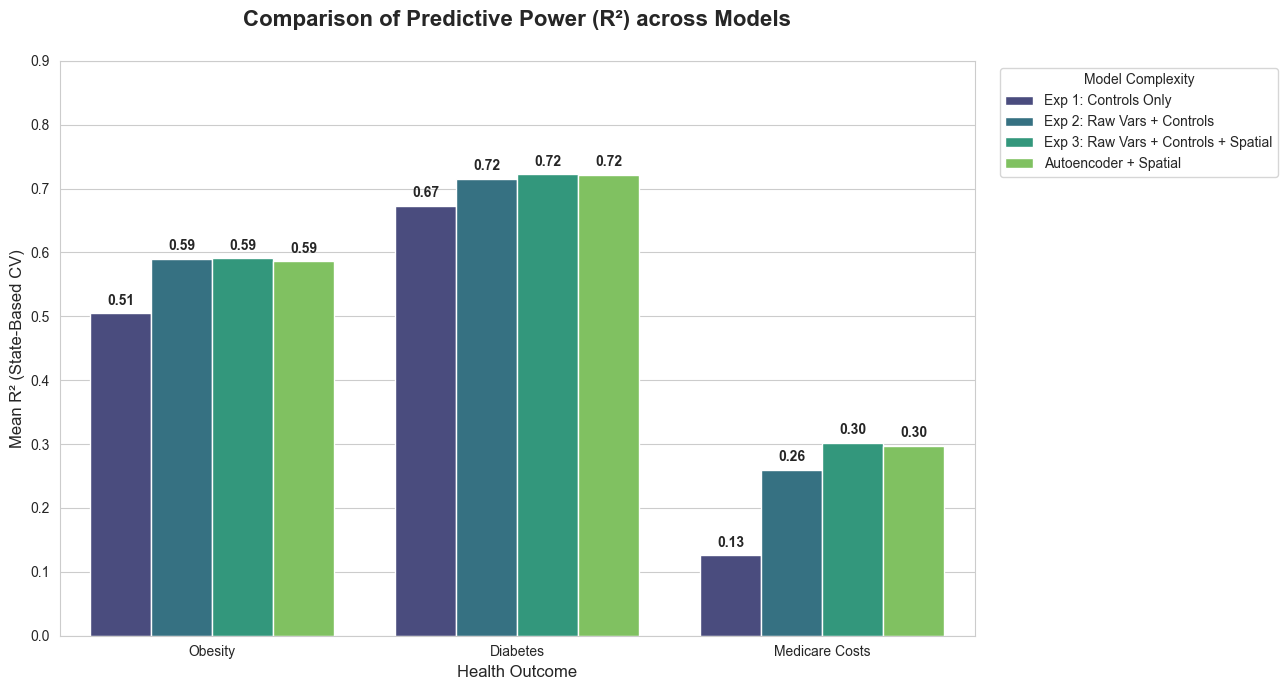

✅ Success: 'final_thesis_comparison_aligned.png' has been saved with all data points matched.


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. LOAD BOTH SETS OF RESULTS
try:
    df_baseline = pd.read_csv('triple_baseline_final_results.csv')
    df_baseline['Category'] = 'Baseline (Raw/Spatial)'
except:
    print("Warning: Could not find triple_baseline_final_results.csv")
    df_baseline = pd.DataFrame()

try:
    df_ae = pd.read_csv('ae3d_state_cv_results.csv')
    # Filter for the BEST experiment (the one with Spatial Lags)
    df_ae = df_ae[df_ae['Experiment'].str.contains('Spatial', na=False)].copy()
    df_ae['Category'] = 'Autoencoder (3D)'
    # Standardize their experiment name for your chart legend
    df_ae['Experiment'] = 'Autoencoder + Spatial'
except:
    print("Warning: Could not find ae3d_state_cv_results.csv")
    df_ae = pd.DataFrame()

# 2. STANDARDIZATION (This fixes the 0.00 issue)
# We map all variations of names to these 3 clean titles
outcome_mapping = {
    'obesity_rate': 'Obesity', 
    'Obesity Rate (%)': 'Obesity',
    'diabetes_rate': 'Diabetes', 
    'Diabetes Rate (%)': 'Diabetes',
    'TOT_MDCR_STDZD_PYMT_PC': 'Medicare Costs', 
    'Medicare Cost Per Capita ($)': 'Medicare Costs'
}

# Apply mapping to ensure both files use the EXACT SAME names
if not df_baseline.empty:
    df_baseline['Outcome'] = df_baseline['Outcome'].map(outcome_mapping).fillna(df_baseline['Outcome'])

if not df_ae.empty:
    df_ae['Outcome'] = df_ae['Outcome'].map(outcome_mapping).fillna(df_ae['Outcome'])

# Combine and find the BEST model (RF or XGB) for each experiment and outcome
all_data = pd.concat([df_baseline, df_ae], ignore_index=True)
best_results = all_data.groupby(['Outcome', 'Experiment', 'Category'])['R2_Mean'].max().reset_index()

# Define specific orders for the chart
exp_order = [
    'Exp 1: Controls Only', 
    'Exp 2: Raw Vars + Controls', 
    'Exp 3: Raw Vars + Controls + Spatial',
    'Autoencoder + Spatial'
]
outcome_order = ['Obesity', 'Diabetes', 'Medicare Costs']

# 3. CREATE THE PLOT
plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=best_results, 
    x='Outcome', 
    y='R2_Mean', 
    hue='Experiment',
    hue_order=exp_order,
    order=outcome_order,
    palette='viridis'
)

# Formatting
plt.title('Comparison of Predictive Power (R²) across Models', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Mean R² (State-Based CV)', fontsize=12)
plt.xlabel('Health Outcome', fontsize=12)
plt.ylim(0, 0.9)
plt.legend(title='Model Complexity', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add values on top of bars
for p in ax.patches:
    val = p.get_height()
    if not np.isnan(val) and val > 0:
        ax.annotate(f'{val:.2f}', 
                    (p.get_x() + p.get_width() / 2., val), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('final_thesis_comparison_aligned.png', dpi=300)
plt.show()

print("✅ Success: 'final_thesis_comparison_aligned.png' has been saved with all data points matched.")


🚀 STARTING SHAP ANALYSIS FOR: Obesity Rate
Training XGBoost on 2168 counties...
Calculating SHAP values...
Generating Global Bar Plot for Obesity Rate...


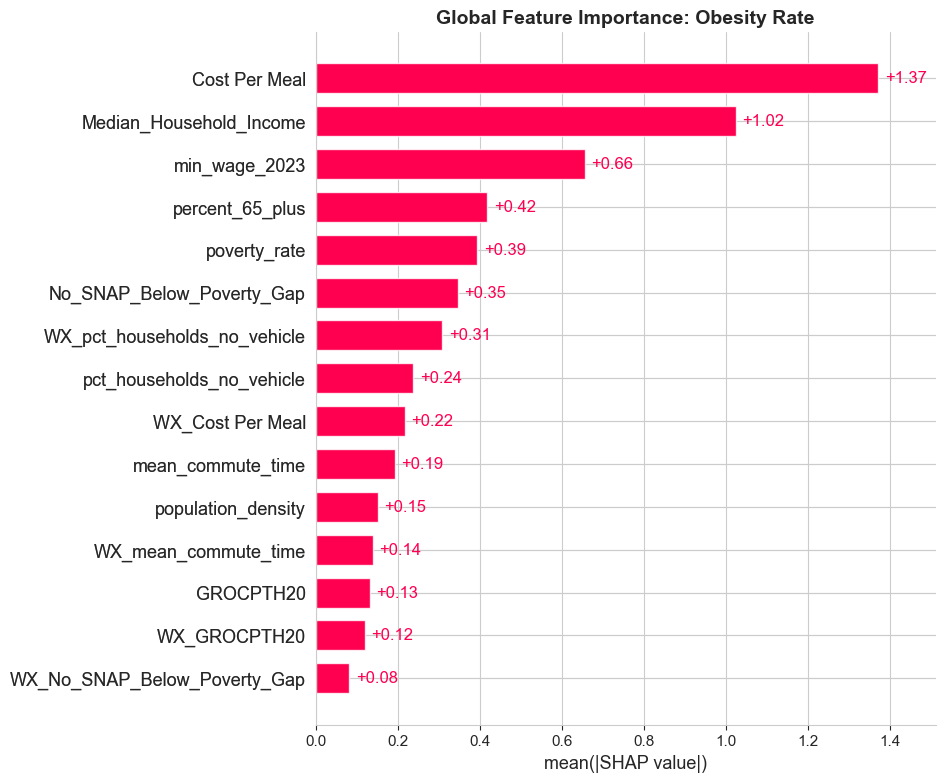


🎯 OBESITY DETECTED: Running deeper local analysis...


<Figure size 1000x600 with 0 Axes>

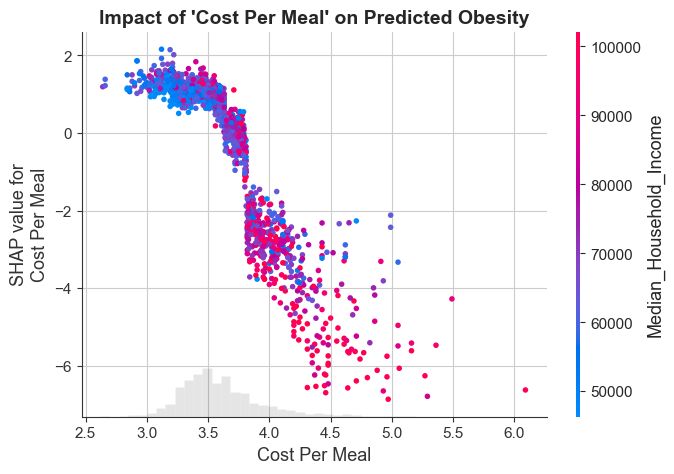

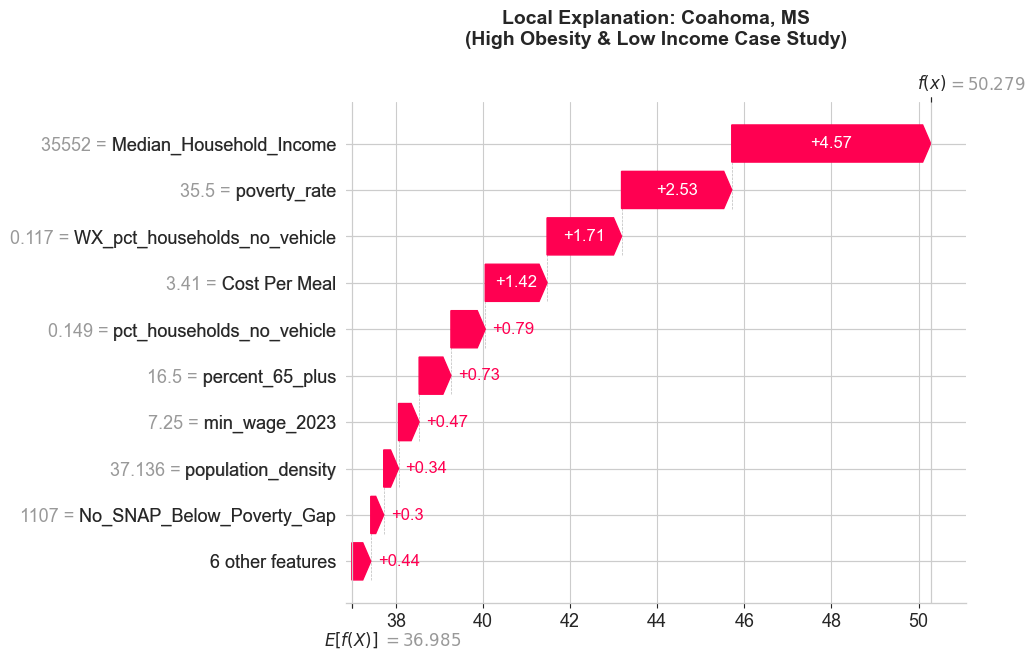


🚀 STARTING SHAP ANALYSIS FOR: Diabetes Rate
Training XGBoost on 2168 counties...
Calculating SHAP values...
Generating Global Bar Plot for Diabetes Rate...


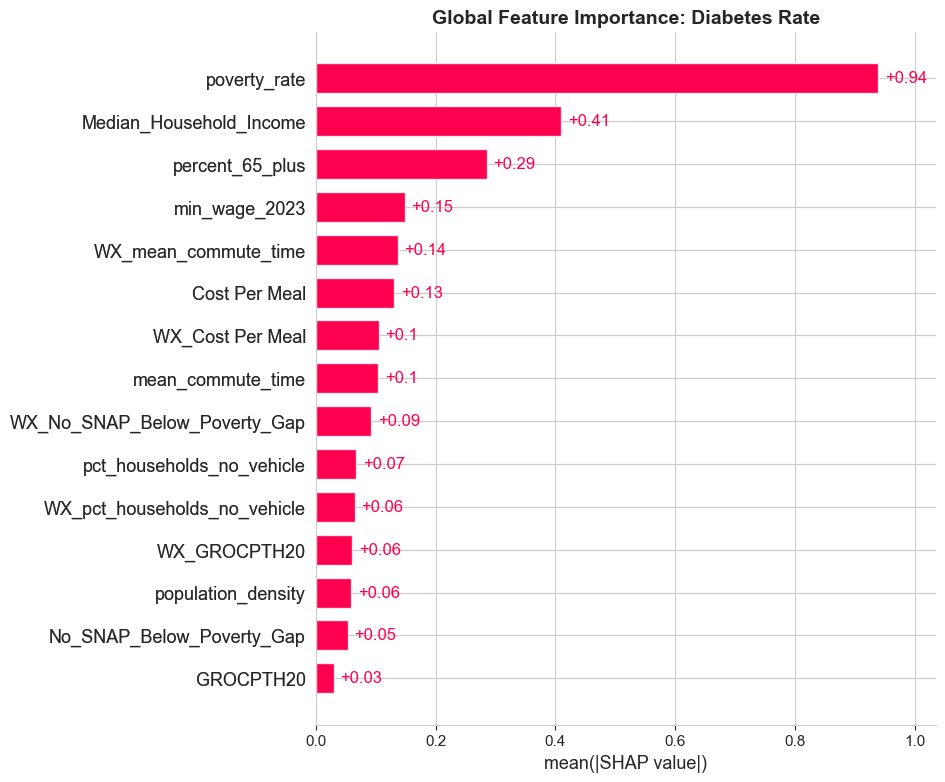


🚀 STARTING SHAP ANALYSIS FOR: Medicare Cost Per Capita
Training XGBoost on 2226 counties...
Calculating SHAP values...
Generating Global Bar Plot for Medicare Cost Per Capita...


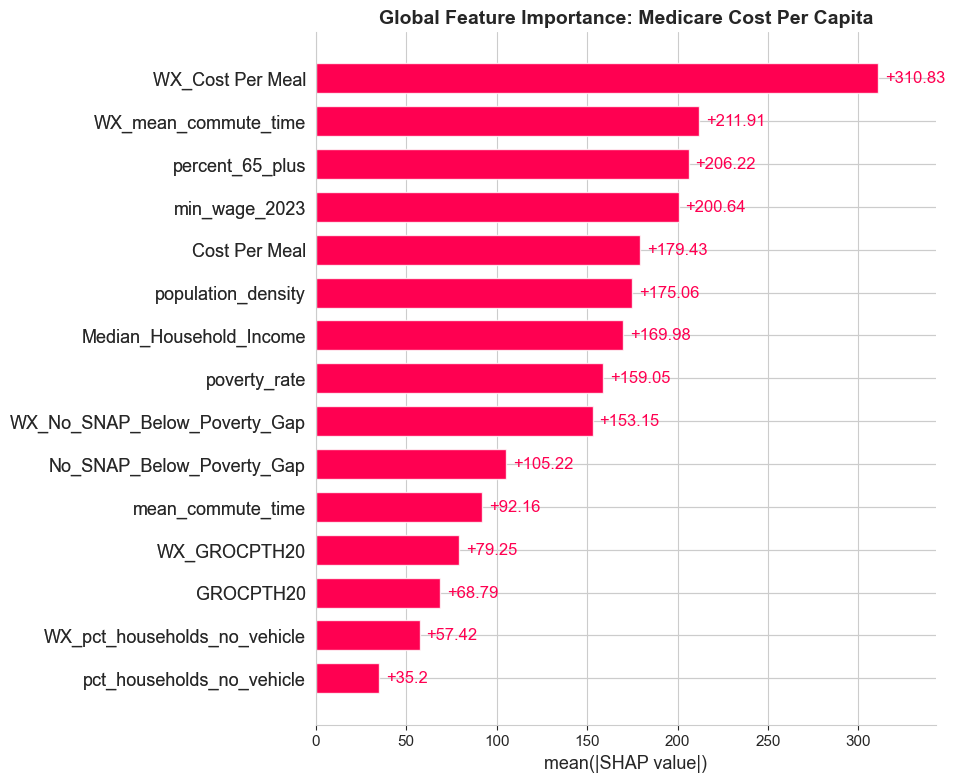


✅ ALL DONE! Check your folder for the 5 saved PNG files.


In [25]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD DATA & DEFINE FEATURES
# ---------------------------------------------------------
df = pd.read_csv('baseline_with_raw_spatial.csv')

# Defining features exactly as they appear in your dataset
CONTROLS = ['min_wage_2023', 'poverty_rate', 'population_density', 'Median_Household_Income', 'percent_65_plus'] 
RAW_FEATURES = ['Cost Per Meal', 'GROCPTH20', 'No_SNAP_Below_Poverty_Gap', 'mean_commute_time', 'pct_households_no_vehicle']
SPATIAL_LAG_FEATURES = ['WX_Cost Per Meal', 'WX_GROCPTH20', 'WX_No_SNAP_Below_Poverty_Gap', 'WX_mean_commute_time', 'WX_pct_households_no_vehicle']

FINAL_FEATURES = CONTROLS + RAW_FEATURES + SPATIAL_LAG_FEATURES

# Define all three targets for the loop
TARGETS = {
    'obesity_rate': 'Obesity Rate',
    'diabetes_rate': 'Diabetes Rate',
    'TOT_MDCR_STDZD_PYMT_PC': 'Medicare Cost Per Capita'
}

# ---------------------------------------------------------
# 2. LOOP THROUGH EACH OUTCOME
# ---------------------------------------------------------
for target_col, target_name in TARGETS.items():
    print(f"\n{'='*50}")
    print(f"🚀 STARTING SHAP ANALYSIS FOR: {target_name}")
    print(f"{'='*50}")
    
    # Clean data specifically for this target (drops NaNs only for the current target)
    df_clean = df.dropna(subset=FINAL_FEATURES + [target_col]).copy()
    df_clean = df_clean.reset_index(drop=True)
    
    X = df_clean[FINAL_FEATURES]
    y = df_clean[target_col]
    
    # Train Model
    print(f"Training XGBoost on {len(df_clean)} counties...")
    model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)
    model.fit(X, y)
    
    # Calculate SHAP Values
    print("Calculating SHAP values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X)
    
    # ---------------------------------------------------------
    # PLOT 1: GLOBAL BAR PLOT (Happens for ALL 3 Targets)
    # ---------------------------------------------------------
    print(f"Generating Global Bar Plot for {target_name}...")
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.title(f"Global Feature Importance: {target_name}", fontsize=14, fontweight='bold')
    plt.savefig(f'shap_1_global_{target_col}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close() # Prevents plots from overlapping in the loop
    
    # ---------------------------------------------------------
    # PLOTS 2 & 3: DEPENDENCE & WATERFALL (OBESITY ONLY)
    # ---------------------------------------------------------
    if target_col == 'obesity_rate':
        print(f"\n🎯 OBESITY DETECTED: Running deeper local analysis...")
        
        # Plot 2: Dependence Plot
        plt.figure(figsize=(10, 6))
        shap.plots.scatter(shap_values[:, "Cost Per Meal"], color=shap_values, show=False)
        plt.title("Impact of 'Cost Per Meal' on Predicted Obesity", fontsize=14, fontweight='bold')
        plt.savefig('shap_2_dependence_obesity.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        # Plot 3: Waterfall Plot (Low Income + High Obesity)
        income_cutoff = df_clean['Median_Household_Income'].quantile(0.25)
        vulnerable_candidates = df_clean[df_clean['Median_Household_Income'] <= income_cutoff]
        
        if not vulnerable_candidates.empty:
            target_idx = vulnerable_candidates[target_col].idxmax()
            county_name = df_clean.loc[target_idx, 'County']
            state_name = df_clean.loc[target_idx, 'State']
        else:
            target_idx = df_clean[target_col].idxmax()
            county_name, state_name = "Max Outcome County", ""
            
        plt.figure(figsize=(12, 8))
        shap.plots.waterfall(shap_values[target_idx], max_display=10, show=False)
        plt.title(f"Local Explanation: {county_name}, {state_name}\n(High Obesity & Low Income Case Study)", fontsize=14, fontweight='bold', pad=20)
        plt.savefig('shap_3_local_waterfall_obesity.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

print("\n✅ ALL DONE! Check your folder for the 5 saved PNG files.")